# tremordb Stage 2 · 多条件纵向 CVAE

**架构**: CNN-1D CVAE，条件向量包含：
- 8种治疗条件（DBS×Med×时间）
- 2种受试者分组（HAT/LAT）

**条件向量编码**:
```
c = one_hot(cond_idx, 8) ⊕ one_hot(group_idx, 2)  → 10维
```

**临床意义**:
- CVAE 学习 p(tremor_velocity | cond, group)
- 能生成 HAT 受试者在 DBS-ON / DBS-OFF 各时间点的合成震颤信号
- 支持配对合成：同一虚拟患者的 DBS-ON 和 DBS-OFF 信号对

**Outputs**: `cvae_best.pt`, `synth_X.npy`, `synth_y.npy`

In [1]:
import os
os.environ.setdefault('OMP_NUM_THREADS','1')
os.environ.setdefault('MKL_NUM_THREADS','1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK','TRUE')

import numpy as np
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
from scipy import signal as sp_signal

torch.set_num_threads(1)  # Mac Intel+conda 必须保持1，否则libomp/MKL冲突崩溃
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)
print('device:', device, '| PyTorch', torch.__version__)

device: cpu | PyTorch 2.2.2


## 1. 加载 Stage 1 数据

In [2]:
X_train = np.load('tremor_X_train.npy'); y_train = np.load('tremor_y_train.npy')
X_val   = np.load('tremor_X_val.npy');   y_val   = np.load('tremor_y_val.npy')

with open('label_dict.json') as f:
    LABELS = json.load(f)

N_COND    = LABELS['n_conditions']   # 8
N_GROUP   = LABELS['n_groups']       # 2
WINDOW_LEN= LABELS['window_len']
FS        = LABELS['sampling_rate']
COND_NAMES= {int(k):v for k,v in LABELS['condition_names'].items()}
GROUP_NAMES= {int(k):v for k,v in LABELS['group_names'].items()}
C_DIM     = N_COND + N_GROUP         # 10 = 8 + 2 条件向量维度

print(f'Train {X_train.shape}  Val {X_val.shape}')
print(f'N_COND={N_COND}  N_GROUP={N_GROUP}  C_DIM={C_DIM}  WINDOW_LEN={WINDOW_LEN}  FS={FS}')

# HAT 训练数据统计
hat_mask_tr = y_train[:,1]==0
lat_mask_tr = y_train[:,1]==1
print(f'\nTrain HAT windows: {hat_mask_tr.sum()}  LAT windows: {lat_mask_tr.sum()}')
for ci in range(N_COND):
    n = ((y_train[:,0]==ci)&hat_mask_tr).sum()
    if n > 0: print(f'  [{ci}] {COND_NAMES[ci]}: {n} HAT windows')

Train (8195, 120)  Val (1153, 120)
N_COND=8  N_GROUP=2  C_DIM=10  WINDOW_LEN=120  FS=100

Train HAT windows: 2981  LAT windows: 5214
  [0] DBS-ON/Med-ON: 312 HAT windows
  [1] DBS-ON/Med-OFF: 355 HAT windows
  [2] DBS-OFF/Med-ON: 561 HAT windows
  [3] DBS-OFF/Med-OFF (t=0): 513 HAT windows
  [4] DBS-OFF/Med-OFF (t=15): 259 HAT windows
  [5] DBS-OFF/Med-OFF (t=30): 368 HAT windows
  [6] DBS-OFF/Med-OFF (t=45): 279 HAT windows
  [7] DBS-OFF/Med-OFF (t=60): 334 HAT windows


## 2. Dataset / DataLoader（平衡采样）

In [3]:
class TremorDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float().unsqueeze(1)  # (N, 1, T)
        self.c = torch.from_numpy(y[:,0]).long()           # cond_idx
        self.g = torch.from_numpy(y[:,1]).long()           # group_idx
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.c[i], self.g[i]


# 按 (cond, group) 联合平衡采样
labels_cg = y_train[:,0] * 2 + y_train[:,1]   # 0..15 (8 cond × 2 group)
counts = np.bincount(labels_cg, minlength=16).astype(np.float32)
counts = np.where(counts==0, 1e9, counts)      # 不出现的类别权重=0
sample_weights = (1.0/counts)[labels_cg]

sampler = WeightedRandomSampler(
    torch.from_numpy(sample_weights).float(),
    num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(TremorDS(X_train, y_train),
                          batch_size=128, sampler=sampler, drop_last=True, num_workers=0)
val_loader   = DataLoader(TremorDS(X_val, y_val),
                          batch_size=64, shuffle=False)
print(f'Batches: train={len(train_loader)}  val={len(val_loader)}')

Batches: train=64  val=19


## 3. CVAE 架构（CNN-1D，10维条件向量）

In [4]:
LATENT_DIM = 16

def conv_block(in_c, out_c, k=7, s=2):
    return nn.Sequential(
        nn.Conv1d(in_c, out_c, k, stride=s, padding=k//2),
        nn.GroupNorm(min(8, out_c), out_c),
        nn.SiLU())

def deconv_block(in_c, out_c, k=7, s=2, last=False):
    layers = [nn.ConvTranspose1d(in_c, out_c, k, stride=s,
                                  padding=k//2, output_padding=1 if s==2 else 0)]
    if not last:
        layers += [nn.GroupNorm(min(8, out_c), out_c), nn.SiLU()]
    return nn.Sequential(*layers)


class CVAE(nn.Module):
    """CNN-1D CVAE：enc_flat 根据 window_len 动态计算，兼容任意采样率"""
    def __init__(self, window_len, c_dim=C_DIM, latent=LATENT_DIM):
        super().__init__()
        self.c_dim  = c_dim
        self.latent = latent
        # Encoder: stride=2 三次，长度缩小8倍
        self.enc = nn.Sequential(conv_block(1,32), conv_block(32,64), conv_block(64,128))
        # 用 dummy input 动态计算 enc_flat（兼容任意 window_len）
        with torch.no_grad():
            dummy    = torch.zeros(1, 1, window_len)
            enc_out  = self.enc(dummy)            # (1, 128, L_out)
            enc_flat = enc_out.flatten(1).shape[1]
            enc_last = enc_out.shape[2]           # L_out
        self._enc_flat = enc_flat
        self._enc_last = enc_last
        print(f'  window_len={window_len} → enc output: 128×{enc_last} → enc_flat={enc_flat}')
        self.fc_mu  = nn.Linear(enc_flat + c_dim, latent)
        self.fc_lv  = nn.Linear(enc_flat + c_dim, latent)
        # Decoder
        self.fc_dec = nn.Linear(latent + c_dim, enc_flat)
        self.dec    = nn.Sequential(deconv_block(128,64), deconv_block(64,32),
                                     deconv_block(32,1,last=True))

    def _c_vec(self, cond_idx, group_idx):
        c = F.one_hot(cond_idx, N_COND).float()
        g = F.one_hot(group_idx, N_GROUP).float()
        return torch.cat([c, g], dim=1)

    def encode(self, x, c_vec):
        h = self.enc(x).flatten(1)
        h = torch.cat([h, c_vec], dim=1)
        return self.fc_mu(h), self.fc_lv(h)

    def reparam(self, mu, lv):
        return mu + (0.5*lv).exp() * torch.randn_like(mu)

    def decode(self, z, c_vec):
        # reshape back to (B, 128, L_out)
        h = self.fc_dec(torch.cat([z, c_vec], dim=1)).view(-1, 128, self._enc_last)
        return self.dec(h)

    def forward(self, x, cond_idx, group_idx):
        c_vec = self._c_vec(cond_idx, group_idx)
        mu, lv = self.encode(x, c_vec)
        z = self.reparam(mu, lv)
        return self.decode(z, c_vec), mu, lv


model = CVAE(window_len=WINDOW_LEN).to(device)
print(f'CVAE params: {sum(p.numel() for p in model.parameters())/1e3:.1f}k')
print(f'C_DIM={C_DIM} (8 condition + 2 group one-hot)')


  window_len=120 → enc output: 128×15 → enc_flat=1920
CVAE params: 258.4k
C_DIM=10 (8 condition + 2 group one-hot)


## 4. Loss Function

In [5]:
FREE_BITS = 0.5

def psd_loss(x, x_hat, n_fft=None):
    n = x.shape[-1] if n_fft is None else n_fft
    spec_r = torch.fft.rfft(x.squeeze(1), n=n)
    spec_h = torch.fft.rfft(x_hat.squeeze(1), n=n)
    p_r = (spec_r.real**2 + spec_r.imag**2) / n
    p_h = (spec_h.real**2 + spec_h.imag**2) / n
    return (p_r - p_h).abs().sum(dim=1).mean()

def cvae_loss(x, x_hat, mu, lv, beta, lam_psd=0.1):
    recon = F.mse_loss(x_hat, x, reduction='none').flatten(1).sum(1).mean()
    psd   = psd_loss(x, x_hat)
    kl    = torch.clamp(
        (-0.5*(1+lv-mu.pow(2)-lv.exp())).mean(0) - FREE_BITS, min=0).sum()
    total = recon + lam_psd * psd + beta * kl
    return total, {'recon': recon.item(), 'psd': psd.item(), 'kl': kl.item()}


# Smoke test
model.train()
xb, cb, gb = next(iter(train_loader))
xb, cb, gb = xb.to(device), cb.to(device), gb.to(device)
xh, mu_s, lv_s = model(xb, cb, gb)
ls, ps = cvae_loss(xb, xh, mu_s, lv_s, beta=0.5)
ls.backward(); model.zero_grad()
print(f'Smoke OK | loss={ls.item():.4f}  recon={ps["recon"]:.2f}  psd={ps["psd"]:.2f}  kl={ps["kl"]:.3f}')

Smoke OK | loss=384.6192  recon=368.59  psd=160.30  kl=0.000


## 5. 训练

In [6]:
N_EPOCHS = 80   # 早停约40-60轮触发；减少上限节省等待时间
WARMUP   = 30
LR       = 1e-3
PATIENCE = 20

opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS, eta_min=1e-5)

history   = {'train':[], 'val':[]}
best_val, best_state, bad = float('inf'), None, 0

for epoch in range(N_EPOCHS):
    beta = min(1.0, epoch/WARMUP)

    # Train
    model.train()
    s = {'recon':0,'psd':0,'kl':0,'total':0,'n':0}
    for x, c, g in train_loader:
        x, c, g = x.to(device), c.to(device), g.to(device)
        xh, mu, lv = model(x, c, g)
        loss, parts = cvae_loss(x, xh, mu, lv, beta)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        for k in parts: s[k] += parts[k]
        s['total'] += loss.item(); s['n'] += 1
    train_avg = {k: v/s['n'] for k,v in s.items() if k!='n'}
    history['train'].append(train_avg)

    # Val
    model.eval()
    sv = {'recon':0,'psd':0,'kl':0,'total':0,'n':0}
    with torch.no_grad():
        for x, c, g in val_loader:
            x, c, g = x.to(device), c.to(device), g.to(device)
            xh, mu, lv = model(x, c, g)
            loss, parts = cvae_loss(x, xh, mu, lv, beta=1.0)
            for k in parts: sv[k] += parts[k]
            sv['total'] += loss.item(); sv['n'] += 1
    val_avg = {k: v/sv['n'] for k,v in sv.items() if k!='n'}
    history['val'].append(val_avg)
    sched.step()

    if epoch < 5 or epoch % 10 == 0 or epoch == N_EPOCHS-1:
        print(f'ep {epoch:3d} β={beta:.2f}  '
              f'recon={train_avg["recon"]:.2f} psd={train_avg["psd"]:.2f} kl={train_avg["kl"]:.3f}  '
              f'| val={val_avg["total"]:.3f}')

    if val_avg['total'] < best_val - 1e-3:
        best_val = val_avg['total']; bad = 0
        best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= PATIENCE and epoch >= WARMUP+10:
            print(f'Early stop @ ep {epoch}  (best val={best_val:.3f})')
            break

if best_state: model.load_state_dict(best_state)
torch.save({'state': model.state_dict(),
            'config': {'window_len':WINDOW_LEN,'n_cond':N_COND,'n_group':N_GROUP,
                       'c_dim':C_DIM,'latent':LATENT_DIM,'fs':FS}},
           'cvae_best.pt')
print('Saved cvae_best.pt')

ep   0 β=0.00  recon=75.32 psd=43.08 kl=122.982  | val=229.077
ep   1 β=0.03  recon=40.36 psd=28.42 kl=69.317  | val=110.764
ep   2 β=0.07  recon=36.67 psd=26.88 kl=41.248  | val=91.165
ep   3 β=0.10  recon=34.83 psd=26.90 kl=33.674  | val=83.914
ep   4 β=0.13  recon=33.56 psd=25.77 kl=29.571  | val=79.964
ep  10 β=0.33  recon=29.29 psd=24.51 kl=19.467  | val=66.098
ep  20 β=0.67  recon=28.11 psd=24.52 kl=12.905  | val=59.711
ep  30 β=1.00  recon=29.39 psd=25.57 kl=8.857  | val=57.952
ep  40 β=1.00  recon=28.42 psd=24.73 kl=8.477  | val=57.877
ep  50 β=1.00  recon=27.62 psd=24.25 kl=8.528  | val=57.773
ep  60 β=1.00  recon=26.17 psd=22.79 kl=8.098  | val=58.162
ep  70 β=1.00  recon=26.52 psd=22.71 kl=8.156  | val=57.707
Early stop @ ep 73  (best val=57.391)
Saved cvae_best.pt


## 6. 生成合成数据（HAT × 所有条件）

In [7]:
N_PER_COND_GROUP = 500   # 每个 (condition, group) 组合生成的合成窗口数

def aggregate_posterior(model, X, y):
    """计算每个 (cond, group) 组合的后验均值和标准差，用于 posterior sampling"""
    model.eval(); stats = {}
    with torch.no_grad():
        for ci in range(N_COND):
            for gi in range(N_GROUP):
                mask = (y[:,0]==ci) & (y[:,1]==gi)
                if mask.sum() < 5: continue
                X_sub = torch.from_numpy(X[mask]).float().unsqueeze(1).to(device)
                c_sub = torch.full((mask.sum(),), ci, dtype=torch.long, device=device)
                g_sub = torch.full((mask.sum(),), gi, dtype=torch.long, device=device)
                mu, lv = model.encode(X_sub, model._c_vec(c_sub, g_sub))
                z = (mu + (0.5*lv).exp()*torch.randn_like(mu)).cpu().numpy()
                stats[(ci,gi)] = {'mean': z.mean(0).astype(np.float32),
                                   'std':  (z.std(0)+1e-3).astype(np.float32)}
    return stats

posterior_stats = aggregate_posterior(model, X_train, y_train)
print(f'Posterior computed for {len(posterior_stats)} (cond, group) pairs')

synth_X_list, synth_y_list = [], []
model.eval()
with torch.no_grad():
    for ci in range(N_COND):
        for gi in range(N_GROUP):
            if (ci, gi) not in posterior_stats: continue
            ps = posterior_stats[(ci,gi)]
            mu = torch.from_numpy(ps['mean']).to(device)
            sd = torch.from_numpy(ps['std']).to(device)
            z  = mu + sd * torch.randn(N_PER_COND_GROUP, LATENT_DIM, device=device)
            c_vec = model._c_vec(
                torch.full((N_PER_COND_GROUP,), ci, dtype=torch.long, device=device),
                torch.full((N_PER_COND_GROUP,), gi, dtype=torch.long, device=device))
            xh = model.decode(z, c_vec).squeeze(1).cpu().numpy()
            synth_X_list.append(xh)
            synth_y_list.append(np.column_stack([
                np.full(N_PER_COND_GROUP, ci),
                np.full(N_PER_COND_GROUP, gi)]))
            print(f'  Generated [{ci},{gi}] {COND_NAMES[ci]} / {LABELS["group_names"][str(gi)]}: '
                  f'{N_PER_COND_GROUP} windows')

synth_X = np.concatenate(synth_X_list).astype(np.float32)
synth_y = np.concatenate(synth_y_list).astype(np.int64)
np.save('synth_X.npy', synth_X)
np.save('synth_y.npy', synth_y)
print(f'\nsynth_X {synth_X.shape}  synth_y {synth_y.shape}')

Posterior computed for 16 (cond, group) pairs
  Generated [0,0] DBS-ON/Med-ON / HAT: 500 windows
  Generated [0,1] DBS-ON/Med-ON / LAT: 500 windows
  Generated [1,0] DBS-ON/Med-OFF / HAT: 500 windows
  Generated [1,1] DBS-ON/Med-OFF / LAT: 500 windows
  Generated [2,0] DBS-OFF/Med-ON / HAT: 500 windows
  Generated [2,1] DBS-OFF/Med-ON / LAT: 500 windows
  Generated [3,0] DBS-OFF/Med-OFF (t=0) / HAT: 500 windows
  Generated [3,1] DBS-OFF/Med-OFF (t=0) / LAT: 500 windows
  Generated [4,0] DBS-OFF/Med-OFF (t=15) / HAT: 500 windows
  Generated [4,1] DBS-OFF/Med-OFF (t=15) / LAT: 500 windows
  Generated [5,0] DBS-OFF/Med-OFF (t=30) / HAT: 500 windows
  Generated [5,1] DBS-OFF/Med-OFF (t=30) / LAT: 500 windows
  Generated [6,0] DBS-OFF/Med-OFF (t=45) / HAT: 500 windows
  Generated [6,1] DBS-OFF/Med-OFF (t=45) / LAT: 500 windows
  Generated [7,0] DBS-OFF/Med-OFF (t=60) / HAT: 500 windows
  Generated [7,1] DBS-OFF/Med-OFF (t=60) / LAT: 500 windows

synth_X (8000, 120)  synth_y (8000, 2)


## 7. 保真度快速检验（DBS效应方向）

In [8]:
from scipy import stats as scipy_stats

def get_tremor_rms(X_arr, y_arr, cond_idx, group_idx):
    mask = (y_arr[:,0]==cond_idx) & (y_arr[:,1]==group_idx)
    if mask.sum() == 0: return np.array([])
    return np.sqrt(np.mean(X_arr[mask]**2, axis=1))

print('=== DBS效应验证：HAT (group=0) DBS-OFF vs DBS-ON 震颤幅度 ===')
print('（期望：DBS-OFF RMS > DBS-ON RMS，即 DBS 有效抑制震颤）\n')

# 条件1=DBS-ON/Med-OFF, 条件3=DBS-OFF/Med-OFF steady
for label, X_arr, y_arr in [('Real (train)', X_train, y_train),
                               ('Synth',       synth_X, synth_y)]:
    rms_on  = get_tremor_rms(X_arr, y_arr, cond_idx=1, group_idx=0)  # DBS-ON
    rms_off = get_tremor_rms(X_arr, y_arr, cond_idx=3, group_idx=0)  # DBS-OFF t=0
    if len(rms_on) > 0 and len(rms_off) > 0:
        print(f'{label}:')
        print(f'  DBS-ON  RMS: {rms_on.mean():.4f} ± {rms_on.std():.4f}')
        print(f'  DBS-OFF RMS: {rms_off.mean():.4f} ± {rms_off.std():.4f}')
        ratio = rms_off.mean() / (rms_on.mean() + 1e-9)
        print(f'  OFF/ON ratio: {ratio:.2f}  (期望 > 1.0)')
        print('  ✓ 方向正确' if rms_off.mean() > rms_on.mean() else '  ✗ 方向错误')
    else:
        print(f'{label}: 条件数据不足')
    print()

=== DBS效应验证：HAT (group=0) DBS-OFF vs DBS-ON 震颤幅度 ===
（期望：DBS-OFF RMS > DBS-ON RMS，即 DBS 有效抑制震颤）

Real (train):
  DBS-ON  RMS: 0.6010 ± 0.8063
  DBS-OFF RMS: 0.9574 ± 0.2578
  OFF/ON ratio: 1.59  (期望 > 1.0)
  ✓ 方向正确

Synth:
  DBS-ON  RMS: 0.5736 ± 0.2175
  DBS-OFF RMS: 0.7929 ± 0.2889
  OFF/ON ratio: 1.38  (期望 > 1.0)
  ✓ 方向正确



## 8. 可视化：washout 轨迹

/var/folders/k_/l97_brvs2h7c4wzphwgqxymm0000gn/T/ipykernel_62146/2646171682.py:24: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/l97_brvs2h7c4wzphwgqxymm0000gn/T/ipykernel_62146/2646171682.py:24: UserWarning: Glyph 20572 (\N{CJK UNIFIED IDEOGRAPH-505C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/l97_brvs2h7c4wzphwgqxymm0000gn/T/ipykernel_62146/2646171682.py:24: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/l97_brvs2h7c4wzphwgqxymm0000gn/T/ipykernel_62146/2646171682.py:24: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/l97_brvs2h7c4wzphwgqxymm0000gn/T/ipykernel_62146/2646171682.py:24: UserWarning: Glyph 38663 (\N{CJK UNIFIED IDEOGRAPH-9707}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/l97_brvs2h7c4wz

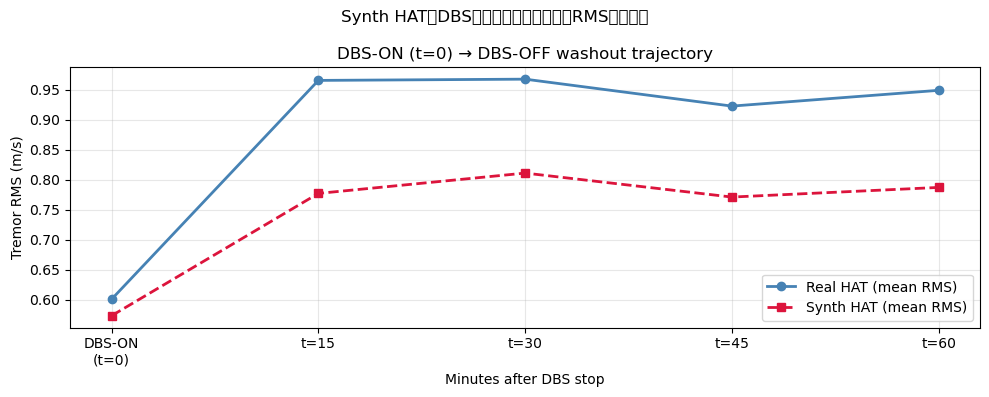

In [9]:
# 展示 HAT 组合成震颤随时间恢复的轨迹
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('Synth HAT：DBS停用后震颤恢复轨迹（RMS随时间）')

t_points = [0, 15, 30, 45, 60]
cond_for_t = {0: 1, 15: 4, 30: 5, 45: 6, 60: 7}  # t→cond_idx for DBS-OFF Med-OFF
rms_real, rms_synth = [], []

for t in t_points:
    ci = cond_for_t[t]
    # Real
    rv = get_tremor_rms(X_train, y_train, ci, 0) if t>0 else get_tremor_rms(X_train,y_train,1,0)
    rms_real.append(rv.mean() if len(rv)>0 else np.nan)
    # Synth
    sv = get_tremor_rms(synth_X, synth_y, ci, 0) if t>0 else get_tremor_rms(synth_X,synth_y,1,0)
    rms_synth.append(sv.mean() if len(sv)>0 else np.nan)

ax.plot(t_points, rms_real,  'o-', color='steelblue', lw=2, label='Real HAT (mean RMS)')
ax.plot(t_points, rms_synth, 's--',color='crimson',   lw=2, label='Synth HAT (mean RMS)')
ax.set_xlabel('Minutes after DBS stop'); ax.set_ylabel('Tremor RMS (m/s)')
ax.set_title('DBS-ON (t=0) → DBS-OFF washout trajectory')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(t_points); ax.set_xticklabels(['DBS-ON\n(t=0)','t=15','t=30','t=45','t=60'])
plt.tight_layout()
plt.savefig('washout_trajectory.png', dpi=130)
plt.show()